In [1]:

using Pkg
Pkg.activate(expanduser("~/Phd/SSDdev"))
Pkg.instantiate()
using Plots
using Unitful
using SolidStateDetectors


using SolidStateDetectors: Electron, Hole

  Activating project at `~/Phd/SSDdev`


In [2]:

T = Float64;
det_rin = 1u"mm"
det_z = det_r = 10u"mm"
z_draw = det_z / 2
pn_r = 8.957282u"mm" # this one was calculated by searching the zero impurity point (displayed in the following section)


8.957282 mm

In [3]:
sim = Simulation{T}(SSD_examples[:TrueCoaxial])
cfn = SSD_examples[:TrueCoaxial]

"/home/ritaferi/Phd/SolidStateDetectors/SolidStateDetectors.jl/examples/example_config_files/public_TrueCoaxial.yaml"

In [4]:
r_list = 0u"mm":0.013u"mm":det_r

(0.0:0.013:9.997) mm

In [5]:
r = 2*z_draw

10.0 mm

In [6]:
sim.detector.semiconductor.impurity_density_model

PtypePNJunctionImpurityDensity{Float64}(ThermalDiffusionLithiumDensity{Float64}(623.0, 1080.0, 2, SolidStateDetectors.var"#38#39"{Float64, SolidStateDetectors.ConstructiveSolidGeometry.Cone{Float64, SolidStateDetectors.ConstructiveSolidGeometry.ClosedPrimitive, Tuple{Tuple{Float64, Float64}, Tuple{Float64, Float64}}, Nothing}}(SolidStateDetectors.ConstructiveSolidGeometry.Cone{Float64, SolidStateDetectors.ConstructiveSolidGeometry.ClosedPrimitive, Tuple{Tuple{Float64, Float64}, Tuple{Float64, Float64}}, Nothing}(((0.01, 0.01), (0.01, 0.01)), nothing, 0.005, CartesianPoint{Float64}(0.0, 0.0, 0.005), [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0])), 1.2039096635950327e23, 1.8136587243923018e-11), ConstantImpurityDensity{Float64}(-1.0e16))

In [8]:
t_ann = 18 * 60
T_ann = 623

R = 1.98
H = 11800
D0 = 2.5e-3

Ns = 10^(21.27 - 2610 / T_ann)
D_Li = D0 * exp(-H / (R * T_ann))

1.7518396803995296e-7

In [9]:
imp_list = map(r -> let pt::CylindricalPoint{T} = CylindricalPoint(r, 0u"°", z_draw)
        SolidStateDetectors.get_impurity_density(sim.detector.semiconductor.impurity_density_model, pt) * 1e-6u"cm^-3"
    end, r_list)

770-element Vector{Quantity{Float64, 𝐋^-3, Unitful.FreeUnits{(cm^-3,), 𝐋^-3, nothing}}}:
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
 -1.0e10 cm^-3
  ⋮
  7.0883864809820936e16 cm^-3
  7.64292155289205e16 cm^-3
  8.215020626921656e16 cm^-3
  8.802700219622933e16 cm^-3
  9.403786913351805e16 cm^-3
  1.0015941005583075e17 cm^-3
  1.063668358851607e17 cm^-3
  1.1263426541995968e17 cm^-3
  1.1893504837529034e17 cm^-3

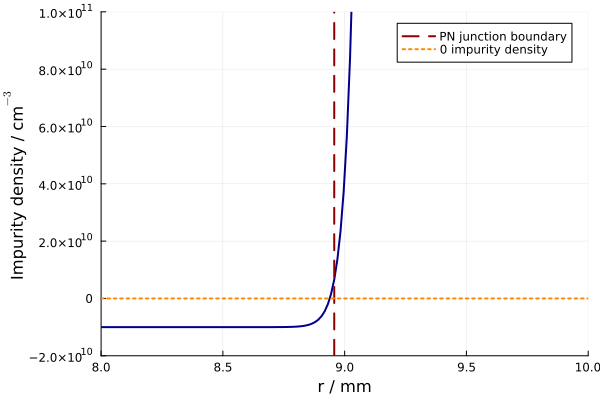

In [10]:
p = plot(r_list, imp_list, xlabel="r / mm", ylabel="Impurity density / cm\$^{-3}\$", unitformat=:nounit, label="",
    color=:darkblue, lw=2, grid=:on, xlims=(8, 10), ylims=(-2e10, 1e11))
vline!([pn_r], lw=2, ls=:dash, color=:darkred, label="PN junction boundary")
hline!([0], lw = 2, ls = :dot, color = :darkorange, label = "0 impurity density")
display(p)

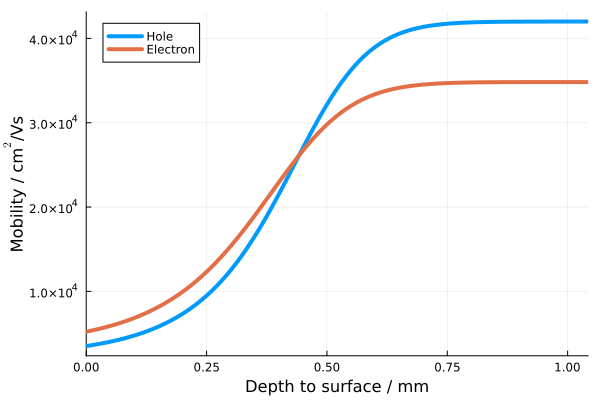

In [11]:
using SolidStateDetectors: Electron, Hole
cdm = sim.detector.semiconductor.charge_drift_model
depth_list = 0u"mm":0.01u"mm":(det_r-pn_r)
mobility_list = map(depth -> let pt::CartesianPoint{T} = CartesianPoint(det_r - depth, 0, z_draw)
    (µh = SolidStateDetectors.calculate_mobility(cdm, pt, Hole) * 10000u"cm^2/(V*s)",
     µe = SolidStateDetectors.calculate_mobility(cdm, pt, Electron) * 10000u"cm^2/(V*s)")
end, depth_list)
plot(depth_list,  getfield.(mobility_list, :µh), label = "Hole", lw = 4)
plot!(depth_list, getfield.(mobility_list, :µe), label = "Electron", lw = 4)
plot!(xlabel = "Depth to surface / mm", ylabel = "Mobility / cm\$^2\$/Vs", unitformat = :nounit, legend = :topleft, xlims = (0u"mm", det_r-pn_r))

-----------

---------

In [12]:
t_ann = 18 * 60 # 18 minutes in seconds
T_ann = 623 
Na = 3*10^9
R = 1.98

H = if 473 <= T_ann <= 873
    11800
else
    10700
end

D0 = if 473 <= T_ann <= 873
    2.5*10^(-3)
else
    1.3*10^(-3)
end

Ns = 10^(21.27 - 2610/T_ann)

1.2039096635950326e17

In [13]:
D_Li = D0 * exp(-H / (R * T_ann))

1.7518396803995296e-7

In [14]:
Nd_func(x) = Ns .* erfc.(x ./ (2 * sqrt(D_Li * t_ann)))
NI_net(x) = Nd_func(x) .- Na
N_neutral = 5.677e15  #cm-3



5.677e15

In [25]:
using Distributions
using SpecialFunctions

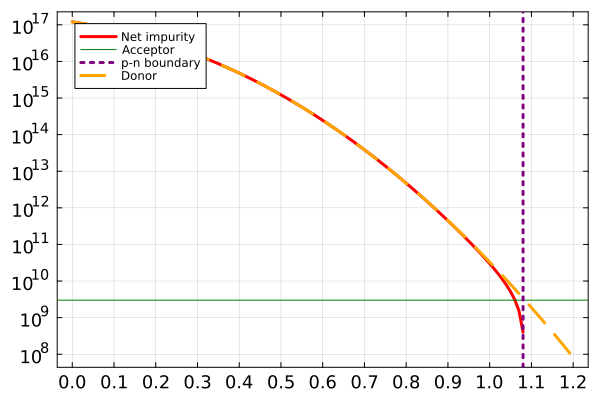

In [26]:
x = 0:0.001: 0.12

idx = findall(abs.(Nd_func.(x) .- Na) .< 1e9)  # tolerance for numerical comparison
x_intersect = x[idx][1]  # take the first intersection

Nd_data =  Ns .* erfc.(x ./ (2 * sqrt(D_Li * t_ann)))
NI_net_data = Nd_data .- Na

mask = NI_net.(x) .> 0

plot(x[mask] .* 10,
     NI_net.(x[mask]),
     label="Net impurity",
     color = :red,
     yscale=:log10,
     frame = :box, lw = 3)
hline!([Na], label="Acceptor", color=:green)

vline!([x_intersect*10], label="p-n boundary", color=:purple, lw=3, ls=:dot)
plot!(x .* 10, Nd_func.(x),
     label="Donor",
     color=:orange,
     ls=:dash, yscale= :log10,
     lw = 3)
plot!(xticks = 0:0.1:1.2, 
     yticks = 10 .^ (0:1:17),
     xguidefontsize = 12,          # dimensione label asse x
    yguidefontsize = 12,          # dimensione label asse y
    tickfontsize = 12,             # dimensione numeri dei tick su entrambi gli assi
    legendfontsize = 8 ,  )

In [27]:
T_diff = 90 #K
x_pos = 0:0.002:0.11

0.0:0.002:0.11

In [28]:
function _calculate_mobility_with_impurities_hole(
    Nn, bulk_imp, surface_imp, temperature)
    Ni = surface_imp .+ bulk_imp
    μI::T = 2.35e19*temperature^1.5/Ni/log(9.13e19*temperature^2/Ni) + 1.51e20*temperature^1.5/Ni/log(5.82e20*temperature^2/Ni)
    μA::T = 7.77e3 * temperature^-1.5
    μN::T = 1e2/Nn * (2.31e18+2.36e20) * 0.82 * (0.228*temperature^0.5 + 0.976*temperature^-0.5)

    1/(1/μI + 1/μA + 1/μN)
end

function _calculate_mobility_with_impurities_electron(
    Nn, bulk_imp, surface_imp, temperature)

    Ni = bulk_imp + surface_imp

    μI::T = 2.442e20*temperature^1.5/Ni/(log(2.496e20*temperature^2/Ni))
    μA::T = 9.32e3 * temperature^-1.5
    μN::T = 1.07e22/Nn * (0.28*temperature^0.5 + 0.54*temperature^-0.5)

    1/(1/μI + 1/μA + 1/μN)
end

_calculate_mobility_with_impurities_electron (generic function with 1 method)

In [29]:
# moltiplicando per 10^4 porto le mobilità da m^2... --> cm^2...

μh = _calculate_mobility_with_impurities_hole.(
    N_neutral.*1e6,
    Na.*1e6,
    Nd_data.*1e6,
    T_diff
) .* 1e4

μe = _calculate_mobility_with_impurities_electron.(
    N_neutral.*1e6,
    Na.*1e6,
    Nd_data.*1e6,
    T_diff
).* 1e4

121-element Vector{Float64}:
  5219.15537908319
  5340.687417338464
  5470.686524424189
  5609.717044914163
  5758.379838417754
  5917.31388455547
  6087.197724052948
  6268.7506640073125
  6462.733659890686
  6669.949769156341
     ⋮
 34824.16316894485
 34824.1661692195
 34824.16840235682
 34824.170058936616
 34824.17128385515
 34824.172186777665
 34824.172850346404
 34824.17333658558
 34824.1736918666

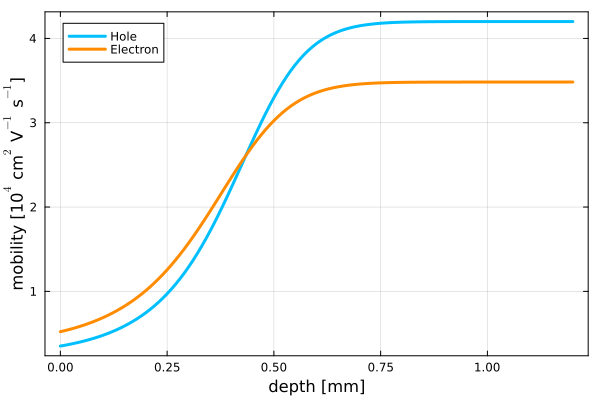

In [30]:
p = plot(x .* 10, μh ./ 10000, label = "Hole", lw = 3, color = :deepskyblue)
plot!(x .* 10, μe ./ 10000, label = "Electron", lw = 3, color = :darkorange)
plot!(xlabel = "depth [mm]",
        ylabel = "mobility [10\$^4\$ cm\$^{2}\$ V\$^{-1}\$ s\$^{-1}\$]",
        frame = :box,
         unitformat = :nounit, legend = :topleft,)
savefig(p, "plot/mobility_curve.png")
display(p)

In [31]:
kB = 1.380649e-23   # J/K
e = 1.602176634e-19 # C
D = (kB * T_diff / e) * μh * 1e-9;



In [32]:
p = plot(x.*10, D.*1e8, lw = 3, label = "")
plot!(xlabel = "depth [mm]", ylabel = "Diffusivity [10\$^8\$cm\$^2\$ ns\$^{-1}\$]",
frame = :box)
hline!([2.89e-7 * 1e8], ls = :dash, lw = 3, color = :green, label = "Giovanetti D")

savefig(p, "plot/diffusion_par.png")

"/home/ritaferi/Phd/ChargeTrappingModel_dev/my model/plot/diffusion_par.png"